In [1]:
from radpy.sedfit import *
from radpy.stellar import *

/home/oxfor/miniforge/envs/test_env/lib/python3.12/site-packages/radpy/sedfit.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Holoviews not imported. Some visualizations will not be available.
PyMultiNest not imported.  MultiNest fits will not work.
/home/oxfor/miniforge/envs/test_env/lib/python3.12/site-packages/astroARIADNE/fitter.py:43: UserWarning: (py)MultiNest installation (or libmultinest.dylib) not detected.
  warnings.warn(


Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


In [2]:
starname = 'HD 158259'
star = StellarParams()
ra_deg, dec_deg, ra_hms, dec_hms = pull_coords(starname, star, verbose = True)
gaia_id = pull_gaia_id(starname, star, verbose = True)


Coordinates in decimal degrees for HD 158259:
RA: 261.35023036706, Dec: 52.79068607998

Coordinates in sexagesimal format for HD 158259:
RA: 17:25:24.05529, Dec: 52:47:26.46989
Found Gaia DR3 ID: Gaia DR3 1416050859226670848


In [3]:
filename = '/mnt/c/Users/oxfor/Research/HD158259/Data/test_photometry.csv'
phot_data = read_in_photometry(filename)

In [4]:
logg = 4.21
dlogg = 0.33
m = 0.0
dm = 0.12

star.logg = logg
star.logg_err = dlogg
star.feh = m
star.feh_err = dm

In [5]:
D, dD = distances('HD 158259', verbose = True)
star.dist = D
star.dist_err = dD

Found Gaia DR3 ID: Gaia DR3 1416050859226670848
Corrected parallax: 36.99638 [mas]
Distance: 27.02967 +/- 0.01451 [pc]


In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress everything but error messages
import tensorflow as tf

# Print devices to check if GPU is being used
print("GPU devices available: ", tf.config.list_physical_devices("GPU"))

GPU devices available:  []


In [7]:
sed_fit = fit_sed(phot_data, star,  [5850, 4.21, 0.0, 0.0],  model = 'phoenix', teffrange = [5000,7000], fitT = True, verbose = True)

Chi squared: 25.410893386781467
Chi squared reduced: 1.4117162992656371
Distance: 27.02967 pc
AV: 0.0 mag
Radius: [np.float64(1.257720915218626)] Rsun
Teff: [np.float64(5798.120455873636)] K
Log g: [4.21] 
Fe/H: 0.0


In [41]:
sed_fit.getr()

0.0

In [8]:
def setaxislabels(exp, unit, logplot = False, fbol_lam = False):
    ##########################################################
    # Function: setaxislabels                                #
    # Inputs:                                                #
    #    unit: string of unit wanted                         #
    #    fbol_lam: flag for fbol_lam                         #
    # Outputs:                                               #
    #    xlab: x axis label                                  #
    #    ylab: y axis label                                  #
    # How it works:                                          #
    #    1. Based on unit chosen, sets x label dependent on  #
    #       unit                                             #
    #    2. Based on unit chosen and if the fbol_lam flag    #
    #       has been set, sets y label                       #
    #    3. Returns x axis and y axis labels                 #
    ##########################################################
    if logplot:
        if fbol_lam:
            ylab = r'$\rm \lambda F_{\lambda}~[\frac{erg}{cm^{2}~s}$]'
        else:
            if unit == 'AA':
                ylab = r'$\rm F_{\lambda}~[\frac{erg}{cm^{2}~s~\AA}$]'
            elif unit == 'micron':
                ylab = r'$\rm F_{\lambda}~[\frac{erg}{cm^{2}~s~\mu m}$]'
        if unit == 'AA':
            xlab = r'$\rm Wavelength~[\AA]$'
        elif unit == 'micron':
            xlab = r'$\rm Wavelength~[\mu m]$'
        return xlab, ylab
    else:
        if fbol_lam:
            #print('Fbol lam')
            #print('Exponent:', exp)
            if exp < 0:
                #print('Exp < 0')
                ylab = rf'$\rm \lambda F_{{\lambda}}~[\times 10^{{{exp}}}~\frac{{\rm erg}}{{\rm cm^2~s}}]$'
            if unit == 'AA':
                #print('angstroms')
                xlab = r'$\rm Wavelength~[\AA]$'
            elif unit == 'micron':
                #print('Microns')
                xlab = r'$\rm Wavelength~[\mu m]$'
            return xlab, ylab
        else:
            #print('No fbol lam')
            #print('Exoponent:', exp)
            if unit == 'AA':
                #print('Angstroms')
                xlab = r'$\rm Wavelength~[\AA]$'
                if exp < 0:
                    #print('exp < 0')
                    ylab = rf'$\rm F_{{\lambda}}~[\times 10^{{{exp}}}~\frac{{\rm erg}}{{\rm cm^2~s~\AA}}]$'
            elif unit == 'micron':
                #print('Microns')
                xlab = r'$\rm Wavelength~[\mu m]$'
                if exp < 0:
                    #print('Exp < 0')
                    ylab = rf'$\rm F_{{\lambda}}~[\times 10^{{{exp}}}~\frac{{\rm erg}}{{\rm cm^2~s~\mu m}}]$'
            return xlab, ylab

In [22]:
def set_values(x, unit, logplot=False, fbol_lam=False, verbose=False):
    ##########################################################
    # Function: set_values                                   #
    # Inputs:                                                #
    #    x: sed object                                       #
    #    unit: unit string                                   #
    #    logPlot: default is False, if True, indicates the   #
    #             log flag                                   #
    #    fbol_lam: default is False, if True, indicates the  #
    #             fbol_lam is flag                           #
    # Outputs:                                               #
    #    litp_xvals: input wavelength                        #
    #    litp_yvals: input flux                              #
    #    litp_dxvals: input wavelength error                 #
    #    litp_dyvals: input flux error                       #
    #    model_xvals: model wavelength                       #
    #    model_yvals: model flux                             #
    #    synth_yvals: model fluxes in the wavelength         #
    #                 bandpasses                             #
    #   residuals: lit flux values minus synth values        #
    # How it works:                                          #
    #    1. Calls convert to generate the model values       #
    #    2. Based on the flags set, converts the values to   #
    #       match what the flags say                         #
    #       logplot: convert everything back into log10      #
    #       fbol_lam: multiply the flux by wavelength        #
    #    3. Returns values                                   #
    ##########################################################
    iwave, iflux, idwave, idflux, mw, mf, msf = convert(x, unit=unit)

    if logplot and fbol_lam:
        # print('set values: Log and lambda')
        model_xvals = np.log10(mw)
        model_yvals = np.log10(mf * mw)
        litp_xvals = np.log10(iwave)
        litp_yvals = np.log10(iwave * iflux)
        litp_dyvals = 0.434 * (idflux / iflux)
        litp_dxvals = 0.434 * (idwave / iwave)
        synth_yvals = np.log10(msf * iwave)
        res = litp_yvals - synth_yvals
        exp = 0
        
        return model_xvals, model_yvals, litp_xvals, litp_yvals, litp_dxvals, litp_dyvals, synth_yvals, res, exp

    if logplot and not fbol_lam:
        # print('set values Log and no lambda')
        model_xvals = np.log10(mw)
        model_yvals = np.log10(mf)
        litp_xvals = np.log10(iwave)
        litp_yvals = np.log10(iflux)
        litp_dyvals = 0.434 * (idflux / iflux)
        litp_dxvals = 0.434 * (idwave / iwave)
        synth_yvals = np.log10(msf)
        res = litp_yvals - synth_yvals
        exp = 0
        return model_xvals, model_yvals, litp_xvals, litp_yvals, litp_dxvals, litp_dyvals, synth_yvals, res, exp

    if not logplot and not fbol_lam:
        # print('set values No log and no lambda')
        number = iflux[0]
        _, exp = normalize_number(number)
        # print('Dividing by:', exp)
        model_xvals = mw
        model_yvals = mf / (10 ** exp)
        litp_xvals = iwave
        litp_yvals = iflux / (10 ** exp)
        litp_dyvals = idflux / (10 ** exp)
        litp_dxvals = idwave
        synth_yvals = msf / (10 ** exp)
        res = litp_yvals - synth_yvals

        return model_xvals, model_yvals, litp_xvals, litp_yvals, litp_dxvals, litp_dyvals, synth_yvals, res, exp

    if not logplot and fbol_lam:
        number = (iflux[0] * iwave[0])
        _, exp = normalize_number(number)
        # print('Dividing by:', exp)
        model_xvals = mw
        model_yvals = (mf * mw) / (10 ** exp)
        litp_xvals = iwave
        litp_yvals = (iflux * iwave) / (10 ** exp)
        litp_dyvals = (idflux) / (10 ** exp)
        litp_dxvals = idwave
        synth_yvals = (msf * iwave) / (10 ** exp)
        res = litp_yvals - synth_yvals

        return model_xvals, model_yvals, litp_xvals, litp_yvals, litp_dxvals, litp_dyvals, synth_yvals, res, exp

In [10]:
def convert_fit_params(star_name, star, fit_params_dict, verbose = False):
    fits = fit_params_dict.get(star_name, {})
    
    fitT = fits['fitTeff']
    fitLG = fits['fitLogg']
    fitFEH = fits['fitFeh']
    fitAV = fits['fitAv']
        
    init_logg = star.logg
    init_feh = star.feh
    init_av = 0
    if fitT:
        teff_range = ast.literal_eval(fits['Trange'])
        init_teff = (teff_range[0] + teff_range[1]) / 2
    else:
        init_teff = 5000
        teff_range = None
    if fitLG:
        logg_range = ast.literal_eval(fits['Loggrange'])
    else:
        logg_range = None
    if fitFEH:
        feh_range = ast.literal_eval(fits['Fehrange'])
    else:
        feh_range = None
    if fitAV:
        av_range = ast.literal_eval(fits['Avrange'])
    else:
        av_range = None

    init_vals = [init_teff, init_logg, init_feh, init_av]
    ranges = [teff_range, logg_range, feh_range, av_range]
    fitflags = [fitT, fitLG, fitFEH, fitAV]
    return init_vals, ranges, fitflags

In [11]:
def set_res_axis(res, logplot = False):
    min_res = np.min(res)
    max_res = np.max(res)

    minres = round(min_res, 1)
    maxres = round(max_res, 1)

    if abs(minres) >= abs(maxres):
        if logplot:
            res_axis_min = (abs(minres)+0.05)*-1
            res_axis_max = abs(minres)+0.05
            res_loc = [abs(minres)*-1, 0, abs(minres)]
            res_labels = [rf'$\rm {val}$' for val in res_loc]
        else:
            res_axis_min = (abs(minres)+0.5)*-1
            res_axis_max = abs(minres)+0.5
            res_loc = [round(abs(minres)*-1), 0, round(abs(minres))]
            res_labels = [rf'$\rm {val}$' for val in res_loc]
    elif abs(minres) <= abs(maxres):
        if logplot:
            res_axis_min = (abs(maxres)+0.05)*-1
            res_axis_max = abs(maxres)+0.05
            res_loc = [abs(maxres)*-1, 0, abs(maxres)]
            res_labels = [rf'$\rm {val}$' for val in res_loc]
        else:
            res_axis_min = (abs(maxres)+0.5)*-1
            res_axis_max = abs(maxres)+0.5
            res_loc = [round(abs(maxres)*-1), 0, round(abs(maxres))]
            res_labels = [rf'$\rm {val}$' for val in res_loc]

    return res_axis_min, res_axis_max, res_loc, res_labels

In [ ]:
def setaxisticklabels(iwave, iflux, exp, unit, set_axis, logplot=False, fbol_lam=False, verbose=False):
    print('setaxisticklabels')
    if set_axis:
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
        if logplot:
            # y-ticks
            y_loc = [round(ymin), round(ymax)]
            y_labels = [rf'$10^{{{y_loc[0]}}}$', rf'$10^{{{y_loc[1]}}}$']

            # x-ticks
            xaxis = np.linspace(xmin, xmax, 5)
            x_loc = []
            xl = []
            for i in range(len(xaxis)):
                xloc = (10 ** (xaxis[i]))

                if unit == 'AA':
                    xl.append(int((round(xloc, -3))))
                    x_loc.append(np.log10((round(xloc, -3))))
                if unit == 'micron':
                    if xloc < 0.8:
                        xl.append(round(xloc, 1))
                        x_loc.append(np.log10(round(xloc, 1))) 
                    else:
                        xl.append(round(xloc))
                        x_loc.append(np.log10(round(xloc)))
            x_labels = [rf'${(val)}$' for val in xl]
            return x_loc, x_labels, y_loc, y_labels
        else:
            if fbol_lam:
                # y ticks
                y_loc = np.linspace(0, ymax / (10 ** exp), 4)
                y_labels = [rf'$\rm {round(val)}$' for val in y_loc]

                # x ticks
                xaxis = np.linspace(xmin, xmax, 5)
                x_loc = []
                xl = []
                for i in range(len(xaxis)):
                    xloc = xaxis[i]
                    if unit == 'AA':
                        xl.append(int((round(xloc, -3))))
                        x_loc.append((round(xloc, -3)))
                    if unit == 'micron':
                        if xloc < 0.8 and xloc > 0:
                            xl.append(round(xloc,2))
                            x_loc.append(round(xloc,2))
                        elif xloc == 0:
                            xl.append(round(xloc))
                            x_loc.append(round(xloc))
                        else:
                            xl.append(np.floor(xloc))
                            x_loc.append(np.floor(xloc))
                            
                x_labels = [rf'${(val)}$' for val in xl]
                return x_loc, x_labels, y_loc, y_labels
            else:
                # y ticks
                y_loc = np.linspace(0, ymax / (10 ** exp), 4)
                y_labels = [rf'$\rm {round(val)}$' for val in y_loc]

                # x ticks
                xaxis = np.linspace(xmin, xmax, 5)
                x_loc = []
                xl = []
                for i in range(len(xaxis)):
                    xloc = xaxis[i]
                    if unit == 'AA':
                        xl.append(int((round(xloc, -3))))
                        x_loc.append((round(xloc, -3)))
                    if unit == 'micron':
                        if xloc < 0.8 and xloc > 0:
                            xl.append(round(xloc,2))
                            x_loc.append(round(xloc,2))
                        elif xloc == 0:
                            xl.append(round(xloc))
                            x_loc.append(round(xloc))
                        else:
                            xl.append(np.floor(xloc))
                            x_loc.append(np.floor(xloc))
                            
                x_labels = [rf'${(val)}$' for val in xl]
                return x_loc, x_labels, y_loc, y_labels

    elif set_axis is None:
        set_axis = set_radpy_axis_limits(iwave, iflux, exp, unit, logplot = logplot)
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
        #print('RADPy definied axis limits:', set_axis)
        #axis is already in np.log10 units
        if logplot:
            #print('Log plot')
            xmin = round((xmin), 1)
            xmax = round((xmax), 1)
            ymin = round(ymin)
            ymax = round(ymax)
            #print('Xmin:', xmin)
            #print('Xmax:', xmax)
            #print('Ymin:', ymin)
            #print('Ymax:', ymax)
            # y ticks
            y_loc = [ymin, ymax]
            y_labels = [rf'$10^{{{y_loc[0]}}}$', rf'$10^{{{y_loc[1]}}}$']
            
            # x ticks
            xaxis = np.linspace(xmin, xmax, 5)
            #xaxis is in np.log10 space
            #print('xaxis:', xaxis)
            x_loc = []
            xl = []
            for i in range(len(xaxis)):
                #converting out of log10 space
                xloc = (10 ** (xaxis[i]))
                #print(f'xloc = 10^{xaxis[i]} -> {xloc}')
                if unit == 'AA':
                    #print('Angstroms')
                    #xlabel is out of log10 space
                    xl.append(int((round(xloc, -3))))
                    #xlocation is in log10 space
                    x_loc.append(np.log10((round(xloc, -3))))
                if unit == 'micron':
                    #print('micron')
                    if xloc < 0.8:
                        #print('xloc < 0.8')
                        #xlabel is out of log10 space
                        xl.append(round(xloc, 1))
                        #xlocation is in log10 space
                        x_loc.append(np.log10(round(xloc, 1)))
                        #print('new x_loc:', x_loc)
                    else:
                        #print('xloc > 0.8')
                        #xlabel is out of log10 space
                        xl.append(round(xloc))
                        #xlocation is in log10 space
                        x_loc.append(np.log10(round(xloc)))
                        #print('new x_loc:', x_loc)

            x_labels = [rf'$\rm {(val)}$' for val in xl]
            #print('X location:', x_loc)
            #print('X labels:', x_labels)
            #print('Y location:', y_loc)
            #print('Y labels:', y_labels)
            return x_loc, x_labels, y_loc, y_labels
        else:
            #print('No log')
            #y axis limits are in 10^exp space
            if fbol_lam:
                #print('Fbol lam')
                # y ticks
                #taking the yvals out of 10^exp space
                yloc = np.linspace(ymin / (10 ** exp), ymax / (10 ** exp), 4)
                y_loc = [round(val) for val in yloc]
                y_labels = [rf'$\rm {round(val)}$' for val in y_loc]

                # x ticks
                xaxis = np.linspace(xmin, xmax, 5)
                x_loc = []
                xl = []
                for i in range(len(xaxis)):
                    xloc = xaxis[i]
                    #print('xloc:', xloc)
                    if unit == 'AA':
                        #print('Angstroms')
                        xl.append(int((round(xloc, -3))))
                        x_loc.append((round(xloc, -3)))
                    if unit == 'micron':
                        #print('Microns')
                        if xloc < 1 and xloc > 0:
                            #print('xloc < 1 and xloc > 0')
                            xl.append(round(xloc,2))
                            x_loc.append(round(xloc,2))
                            #print('new x_loc:', x_loc)
                        elif xloc == 0:
                            #print('xloc = 0')
                            xl.append(round(xloc))
                            x_loc.append(round(xloc))
                            #print('new x_loc:', x_loc)
                        else:
                            #print('xloc > 1')
                            #print("xloc mod1:", xloc%1)
                            if xloc%1 < 0.5:
                                #print("xlocmod1 < 0.5")
                                xl.append(round(np.floor(xloc)))
                                x_loc.append(round(np.floor(xloc)))
                            elif xloc%1 > 0.5:
                                #print("xlocmod1 > 0.5")
                                xl.append(round((xloc)))
                                x_loc.append(round((xloc)))
                            
                x_labels = [rf'${(val)}$' for val in xl]
                #print('X location:', x_loc)
                #print('X labels:', x_labels)
                #print('Y location:', y_loc)
                #print('Y labels:', y_labels)
                return x_loc, x_labels, y_loc, y_labels
            else:
                #print('No fbol_lam')
                # y ticks
                yloc = np.linspace(1, ymax / (10 ** exp), 4)
                y_loc = [round(val) for val in yloc]
                y_labels = [rf'$ \rm {round(val)}$' for val in y_loc]
                print('setaxisticklabels')
                print('ymin:', ymin / (10**exp))
                print('y_loc:', y_loc)
                # x ticks
                xaxis = np.linspace(xmin, xmax, 5)
                x_loc = []
                xl = []
                for i in range(len(xaxis)):
                    xloc = xaxis[i]
                    #print('xloc:', xloc)
                    if unit == 'AA':
                        #print('angstroms')
                        xl.append(int((round(xloc, -3))))
                        x_loc.append((round(xloc, -3)))
                    if unit == 'micron':
                        #print('microns')
                        if xloc < 1 and xloc > 0:
                            #print('xloc < 1 and xloc > 0')
                            xl.append(round(xloc,2))
                            x_loc.append(round(xloc,2))
                            #print('new x_loc:', x_loc)
                        elif xloc == 0:
                            #print('xloc = 0')
                            xl.append(round(xloc))
                            x_loc.append(round(xloc))
                            #print('new x_loc:', x_loc)
                        else:
                            #print('xloc > 1')
                            #print("xloc mod1:", xloc%1)
                            if xloc%1 < 0.5:
                                #print("xlocmod1 < 0.5")
                                xl.append(round(np.floor(xloc)))
                                x_loc.append(round(np.floor(xloc)))
                            elif xloc%1 > 0.5:
                                #print("xlocmod1 > 0.5")
                                xl.append(round((xloc)))
                                x_loc.append(round((xloc)))
                                
                            #print('new x_loc:', x_loc)
                            
                x_labels = [rf'${(val)}$' for val in xl]
                #print('X location:', x_loc)
                #print('X labels:', x_labels)
                #print('Y location:', y_loc)
                #print('Y labels:', y_labels)
                return x_loc, x_labels, y_loc, y_labels

In [17]:
def setaxisticklabels(iwave, iflux, exp, unit, set_axis, logplot=False, fbol_lam=False, verbose=False):
    if set_axis:
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
    elif set_axis is None:
        set_axis = set_radpy_axis_limits(iwave, iflux, exp, unit, logplot = logplot)
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
        
    if logplot:
        xmin = round((xmin), 1)
        xmax = round((xmax), 1)
        ymin = round(ymin)
        ymax = round(ymax)
        # y ticks
        y_loc = [ymin, ymax]
        y_labels = [rf'$10^{{{y_loc[0]}}}$', rf'$10^{{{y_loc[1]}}}$']
            
        # x ticks
        xaxis = np.linspace(xmin, xmax, 5)
        #xaxis is in np.log10 space
        x_loc = []
        xl = []
        for i in range(len(xaxis)):
            #converting out of log10 space
            xloc = (10 ** (xaxis[i]))
            if unit == 'AA':
                #xlabel is out of log10 space
                xl.append(int((round(xloc, -3))))
                #xlocation is in log10 space
                x_loc.append(np.log10((round(xloc, -3))))
            if unit == 'micron':
                if xloc < 0.8:
                    #xlabel is out of log10 space
                    xl.append(round(xloc, 1))
                    #xlocation is in log10 space
                    x_loc.append(np.log10(round(xloc, 1)))
                else:
                    #xlabel is out of log10 space
                    xl.append(round(xloc))
                    #xlocation is in log10 space
                    x_loc.append(np.log10(round(xloc)))

        x_labels = [rf'$\rm {(val)}$' for val in xl]
        return x_loc, x_labels, y_loc, y_labels
    else:
        #y axis limits are in 10^exp space
        if fbol_lam:
            # y ticks
            #taking the yvals out of 10^exp space
            yloc = np.linspace(ymin / (10 ** exp), ymax / (10 ** exp), 4)
            y_loc = [round(val) for val in yloc]
            y_labels = [rf'$\rm {round(val)}$' for val in y_loc]

            # x ticks
            xaxis = np.linspace(xmin, xmax, 5)
            x_loc = []
            xl = []
            for i in range(len(xaxis)):
                xloc = xaxis[i]
                if unit == 'AA':
                    xl.append(int((round(xloc, -3))))
                    x_loc.append((round(xloc, -3)))
                if unit == 'micron':
                    if xloc < 1 and xloc > 0:
                        xl.append(round(xloc,2))
                        x_loc.append(round(xloc,2))
                    elif xloc == 0:
                        xl.append(round(xloc))
                        x_loc.append(round(xloc))
                    else:
                        if xloc%1 < 0.5:
                            xl.append(round(np.floor(xloc)))
                            x_loc.append(round(np.floor(xloc)))
                        elif xloc%1 > 0.5:
                            xl.append(round((xloc)))
                            x_loc.append(round((xloc)))
                            
            x_labels = [rf'${(val)}$' for val in xl]
            return x_loc, x_labels, y_loc, y_labels
        else:
            # y ticks
            yloc = np.linspace(1, ymax / (10 ** exp), 4)
            y_loc = [round(val) for val in yloc]
            y_labels = [rf'$ \rm {round(val)}$' for val in y_loc]
            # x ticks
            xaxis = np.linspace(xmin, xmax, 5)
            x_loc = []
            xl = []
            for i in range(len(xaxis)):
                xloc = xaxis[i]
                if unit == 'AA':
                    xl.append(int((round(xloc, -3))))
                    x_loc.append((round(xloc, -3)))
                if unit == 'micron':
                    if xloc < 1 and xloc > 0:
                        xl.append(round(xloc,2))
                        x_loc.append(round(xloc,2))
                    elif xloc == 0:
                        xl.append(round(xloc))
                        x_loc.append(round(xloc))
                    else:
                        if xloc%1 < 0.5:
                            xl.append(round(np.floor(xloc)))
                            x_loc.append(round(np.floor(xloc)))
                        elif xloc%1 > 0.5:
                            xl.append(round((xloc)))
                            x_loc.append(round((xloc)))
                            
            x_labels = [rf'${(val)}$' for val in xl]
            return x_loc, x_labels, y_loc, y_labels

In [23]:
def set_radpy_axis_limits(w, f, exp, unit, logplot):
    ##########################################################
    # Function: set_axis_labels                              #
    # Inputs:                                                #
    #    mw: model wavelength array                          #
    #    mf: model flux array                                #
    #    unit: string of unit wanted                         #
    #    fbol_lam: flag for fbol_lam                         #
    # Outputs:                                               #
    #    set_axis: the axis limits in the format of          #
    #              [xmin, xmax, ymin, ymax]                  #
    # How it works:                                          #
    #    1. Based on unit chosen and fbol_lam flag setting,  #
    #       sets the axis limits based on the minimum of the #
    #       arrays  and maxs of the arrays                   #
    #    2. Returns the sxis limits                          #
    ##########################################################
    xmin = min(w)
    xmax = max(w)
    ymin = min(f)
    ymax = max(f)

    
    if unit == 'AA':
        if logplot:
            Xmin = xmin-(xmin*0.05)
            Xmax = xmax+(xmax*0.05)
            Ymin = ymin+(ymin*0.05)
            Ymax = ymax-(ymax*0.05)

            new_axis = [round(Xmin, 1),round(Xmax, 1), round(Ymin)*(10**(exp)), round(Ymax)*(10**(exp))]

            return new_axis
        else:
            Xmin = xmin-(xmin*0.1)
            Xmax = xmax+(xmax*0.1)
            Ymin = ymin+(ymin*0.1)
            Ymax = ymax+(ymax*0.2)

            new_axis = [round(Xmin, -2), round(Xmax,-3), round(Ymin, 1)*(10**(exp)), round(Ymax)*(10**(exp))]

            return new_axis
    if unit == 'micron':
        if logplot:
            Xmin = xmin-(xmin*0.05)
            Xmax = xmax+(xmax*0.05)
            Ymin = ymin+(ymin*0.01)
            Ymax = ymax-(ymax*0.01)
            
            new_axis = [round(Xmin, 2),round(Xmax, 2), round(Ymin)*(10**(exp)), round(Ymax)*(10**(exp))]

            return new_axis
        else:
            Xmin = xmin-(xmin*0.05)
            Xmax = xmax+(xmax*0.05)
            Ymin = ymin-(ymin*0.05)
            Ymax = ymax+(ymax*0.1)
            
            new_axis = [round(Xmin, 2), round(Xmax,2), round(Ymin, 1)*(10**(exp)), round(Ymax,1)*(10**(exp))]

            return new_axis

In [ ]:
def setaxislimits(iwave, iflux, exp, unit, set_axis, logplot=False, fbol_lam=False):
    print('setaxislimits:')
    if set_axis:
        #print('User definied axis limits:', set_axis)
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
        if logplot:
            #print('Log plot')
            #print('Xlimit: ', xmin - 0.1, xmax + 0.1)
            #print('ylimit: ', ymin - 0.1, ymax + 0.1)
            return xmin - 0.1, xmax + 0.1, ymin - 0.1, ymax + 0.1
        else:
            #print('no log plot')
            #if fbol_lam:
                #print('Flam')
            #else:
                #print('No flam')
            if unit == 'AA':
                #print('X limits:', xmin - 500, xmax + 500)
                #print('Y limits:', (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25)
                return xmin - 500, xmax + 500, (ymin / (10 ** (exp))) + 0.25, (ymax / (10 ** (exp))) - 0.25
            if unit == 'micron':
                #print('X limits:', xmin - 0.1, xmax + 0.1)
                #print('Y limits: ', (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25)
                return xmin - 0.1, xmax + 0.1, (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25

    else:
        set_axis = set_radpy_axis_limits(iwave, iflux, exp, unit, logplot = logplot)
        print('RADPy definied axis limits:', set_axis)
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]

        if logplot:
            #output of set_radpy_axis_limits are in log10 space
            #print('log plot')
            xmin = round((xmin), 1)
            xmax = round((xmax), 1)
            ymin = round((ymin), 1)
            ymax = round((ymax), 1)
            #print('X limits:', xmin - 0.1, xmax + 0.1)
            #print('Y limits:', ymin + 0.2, ymax + 0.1)
            return xmin - 0.1, xmax + 0.1, ymin - 0.5, ymax + 0.1

        else:
            #output of set_radpy_axis_limits are in yvals * 10^exp
            #print('No log plot')
            #if fbol_lam:
                #print('Flam')
            #else:
                #print('No flam')
            if unit == 'AA':
                print('X limits:', xmin - 500, xmax + 500)
                print('Y limits: ', (ymin / (10 ** (exp))) + 1, (ymax / (10 ** (exp))) + 0.25)
                return xmin - 500, xmax + 500, ((ymin) / (10 ** (exp)))-0.25, (ymax / (10 ** (exp))) + 0.25
            if unit == 'micron':
                #print('X limits:', xmin - 0.1, xmax + 0.1)
                #print('Y limits: ', (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25)
                return xmin - 0.1, xmax + 0.1, (ymin / (10 ** (exp))) -0.25, (ymax / (10 ** (exp))) + 0.25

In [19]:
def setaxislimits(iwave, iflux, exp, unit, set_axis, logplot=False, fbol_lam=False):
    if set_axis:
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
    else:
        set_axis = set_radpy_axis_limits(iwave, iflux, exp, unit, logplot = logplot)
        xmin = set_axis[0]
        xmax = set_axis[1]
        ymin = set_axis[2]
        ymax = set_axis[3]
        
    if logplot:
        return xmin - 0.1, xmax + 0.1, ymin - 0.5, ymax + 0.1
    else:
        if unit =='AA':
            return xmin - 500, xmax + 500, (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25
        if unit == 'micron':
            return xmin - 0.1, xmax + 0.1, (ymin / (10 ** (exp))) - 0.25, (ymax / (10 ** (exp))) + 0.25


In [24]:
def plot_sed(x, unit, logplot=True, fbol_lam=True, set_axis=None, title=None, savefig=None, uselatex = False, show=True, verbose=False):
    ##########################################################
    # Function: plot_sed                                     #
    # Inputs:                                                #
    #    x: sed object                                       #
    #    unit: unit chosen                                   #
    #    logplot: log flag                                   #
    #             if True, sets plot in log space            #
    #    fbol_lam: fbol_lam flag                             #
    #             if True, multiplies the flux by wavelength #
    #    set_axis: allows user to set their axis limits      #
    #             if None, will set based on the model vals  #
    #    title: allows user to set the plot title            #
    #    savefig: allows user to save fig                    #
    #            give a filename                             #
    #    show: shows Figure                                  #
    # Outputs:                                               #
    #    displays the plot                                   #
    # How it works:                                          #
    #    1. Determines the axis limits based on user input   #
    #       and flags set                                    #
    #    2. Calls set_values to generate the data to be      #
    #       plotted                                          #
    #    3. Plots everything                                 #
    ##########################################################

    #iwave, iflux, idwave, idflux, mw, mf, msf = convert(x, unit)

    plt.rcParams.update({'font.size': 15})
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['text.usetex'] = uselatex

    f, axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [10, 3]}, sharex=True)

    model_xvals, model_yvals, litp_xvals, litp_yvals, litp_dxvals, litp_dyvals, synth_yvals, res, exp = set_values(x, unit,
                                                                                                                   logplot=logplot,
                                                                                                                   fbol_lam=fbol_lam,
                                                                                                                   verbose=verbose)
    xmin, xmax, ymin, ymax = setaxislimits(litp_xvals, litp_yvals, exp, unit, set_axis, logplot=logplot, fbol_lam=fbol_lam)
    xloc, xlabels, yloc, ylabels = setaxisticklabels(litp_xvals, litp_yvals, exp, unit, set_axis, logplot=logplot, fbol_lam=fbol_lam)

    axes[0].set_ylim(ymin, ymax)
    axes[1].set_xlim(xmin, xmax)
    axes[0].set_yticks(yloc)
    axes[0].set_yticklabels(ylabels)
    axes[1].set_xticks(xloc)
    axes[1].set_xticklabels(xlabels)

    axes[0].plot(model_xvals, model_yvals, 'g', linewidth=1, label=r'$\rm Model~Spectrum$')
    axes[0].plot(litp_xvals, litp_yvals, 'b.', markersize=10, markerfacecolor='none', label=r'$\rm Photometry$')
    axes[0].errorbar(litp_xvals, litp_yvals, xerr=litp_dxvals, yerr=litp_dyvals, fmt='.', markerfacecolor='none',
                     color='blue', capsize=3)
    axes[0].plot(litp_xvals, synth_yvals, 'r.', markersize=10, label=r'$\rm Synthetic~Photometry $')

    axes[0].legend(prop={'size': 10}, loc='best')
    axes[0].tick_params(axis='x', labelbottom=False)

    axes[1].plot(litp_xvals, res, 'k.')
    axes[1].errorbar(litp_xvals, res, yerr=litp_dyvals, fmt='.', color='black')
    axes[1].axhline(y=0)
    ramin, ramax, rloc, rlabel = set_res_axis(res, logplot = logplot)
    axes[1].set_ylim(ramin, ramax)
    axes[1].set_yticks(rloc)
    axes[1].set_yticklabels(rlabel)
    if logplot:
        if unit == 'micron':
            axes[1].set_ylabel(r'$\rm Residuals$', labelpad=5)
        if unit == 'AA':
            axes[1].set_ylabel(r'$\rm Residuals$', labelpad=5)
    else:
        if unit == 'micron':
            axes[1].set_ylabel(r'$\rm Residuals$', labelpad=0)
        if unit == 'AA':
            axes[1].set_ylabel(r'$\rm Residuals$', labelpad=0)

    xlab, ylab = setaxislabels(exp, unit, logplot=logplot, fbol_lam=fbol_lam)
    axes[1].set_xlabel(xlab)
    axes[0].set_ylabel(ylab)
    plt.subplots_adjust(wspace=0, hspace=0)
    axes[0].xaxis.set_minor_locator(AutoMinorLocator())
    axes[0].yaxis.set_minor_locator(AutoMinorLocator())
    axes[1].xaxis.set_minor_locator(AutoMinorLocator())
    axes[1].yaxis.set_minor_locator(AutoMinorLocator())

    if title:
        axes[0].set_title(title)
    if savefig:
        f.savefig(savefig, bbox_inches='tight')
    if show:
        plt.show()

    return f, axes

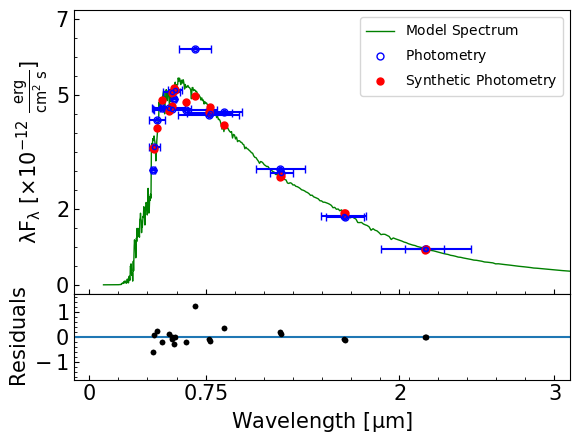

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: ylabel='$\\rm \\lambda F_{\\lambda}~[\\times 10^{-12}~\\frac{\\rm erg}{\\rm cm^2~s}]$'>,
        <Axes: xlabel='$\\rm Wavelength~[\\mu m]$', ylabel='$\\rm Residuals$'>],
       dtype=object))

In [36]:
#set_axis = [-0.5, 0.5, -12, -11]      # log plot, flam, micron
#set_axis = [-0.5, 0.5, -12, -10.8]    # log plot, no flam, micron
set_axis = [0, 3, 0e-12, 7e-12]       # no log plot, flam, micron
#set_axis = [0.0, 3, 0e-12, 12e-12 ]     # no log plt, no flam, micron

#set_axis = [3.5, 4.5, -8, -7]         # log plot, flam, AA
#set_axis = [3.5, 4.5, -13, -10.7]     # log plot, no flam, AA
#set_axis = [0, 30000, 0e-8, 7e-8]     # no log plot, flam, AA
#set_axis = [0, 30000, 0e-12, 11e-12]  # no log plot, no flam, AA

#set_axis = None

plot_sed(sed_fit, 'micron', logplot = False, fbol_lam = True, set_axis = set_axis, title = None, savefig = None, show = True)